<a href="https://colab.research.google.com/github/ronniedebojit2002-netizen/Data-Intelligence-System/blob/main/Part2_MachineLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Applied AI & ML Capstone Project

# Part 2: Supervised Machine Learning Model – Build, Train, and Evaluate

**Student:** Debojit Lahiri

---

## Objective

The objective of Part 2 is to build and evaluate supervised machine learning models using the cleaned dataset generated in Part 1. A regression model is developed to predict house prices, while a binary classification model predicts whether a house belongs to the high-price category. Proper preprocessing techniques are applied to avoid data leakage, and model performance is evaluated using appropriate regression and classification metrics.

In [2]:
# Part 2 - Supervised Machine Learning
# Applied AI & ML Capstone Project

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Encoding
from sklearn.preprocessing import OrdinalEncoder

# Regression
from sklearn.linear_model import LinearRegression, Ridge

# Classification
from sklearn.linear_model import LogisticRegression

# Metrics
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [3]:
housing_df = pd.read_csv("cleaned_data.csv")

housing_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
print("Shape:", housing_df.shape)

housing_df.info()

Shape: (1460, 81)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int

## 1. Feature Matrix and Target Variables

The cleaned dataset is used to define the feature matrix and target variables.

- **Regression Target (`y_reg`)**: SalePrice
- **Classification Target (`y_clf`)**: A binary target created by comparing SalePrice with its median value.

In [5]:
# Regression target
y_reg = housing_df["SalePrice"]

# Classification target
y_clf = (housing_df["SalePrice"] > housing_df["SalePrice"].median()).astype(int)

# Feature matrix
X = housing_df.drop(columns=["SalePrice"])

print("Feature Matrix Shape:", X.shape)
print("Regression Target Shape:", y_reg.shape)
print("Classification Target Shape:", y_clf.shape)

Feature Matrix Shape: (1460, 80)
Regression Target Shape: (1460,)
Classification Target Shape: (1460,)


In [6]:
# Identify categorical columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns

print("Number of categorical columns:", len(categorical_cols))
print(categorical_cols.tolist())

Number of categorical columns: 43
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


## 2. Ordinal Encoding

Ordinal categorical variables have a natural ranking (for example: Poor < Fair < Typical < Good < Excellent). These variables are encoded while preserving their order.

In [7]:
# Ordered mapping used in the Ames Housing dataset
quality_map = {
    "Po": 1,
    "Fa": 2,
    "TA": 3,
    "Gd": 4,
    "Ex": 5
}

ordinal_features = [
    "ExterQual",
    "ExterCond",
    "KitchenQual",
    "HeatingQC"
]

# Create a copy
X_encoded = X.copy()

for col in ordinal_features:
    if col in X_encoded.columns:
        X_encoded[col] = X_encoded[col].map(quality_map)

## 3. One-Hot Encoding

Nominal categorical variables do not have a natural ordering. Therefore, One-Hot Encoding is applied to convert them into binary indicator variables while avoiding false ordinal relationships. The first dummy variable is dropped to reduce multicollinearity.

In [8]:
# Remaining categorical columns
remaining_cat = X_encoded.select_dtypes(include=['object', 'category']).columns

X_encoded = pd.get_dummies(
    X_encoded,
    columns=remaining_cat,
    drop_first=True
)

print("Shape after encoding:", X_encoded.shape)

Shape after encoding: (1460, 235)


In [9]:
print("Remaining Missing Values:")
print(X_encoded.isnull().sum().sum())

Remaining Missing Values:
0


## 4. Train-Test Split and Feature Scaling

The dataset is divided into training and testing sets using an 80:20 split.

A StandardScaler is fitted **only on the training data** to avoid data leakage. The fitted scaler is then used to transform both the training and testing feature sets.

In [10]:
# Split for regression
X_train_reg, X_test_reg, y_reg_train, y_reg_test = train_test_split(
    X_encoded,
    y_reg,
    test_size=0.2,
    random_state=42
)

# Split for classification
X_train_clf, X_test_clf, y_clf_train, y_clf_test = train_test_split(
    X_encoded,
    y_clf,
    test_size=0.2,
    random_state=42
)

print("Regression Training Shape:", X_train_reg.shape)
print("Regression Testing Shape:", X_test_reg.shape)

print("\nClassification Training Shape:", X_train_clf.shape)
print("Classification Testing Shape:", X_test_clf.shape)

Regression Training Shape: (1168, 235)
Regression Testing Shape: (292, 235)

Classification Training Shape: (1168, 235)
Classification Testing Shape: (292, 235)


In [11]:
# Regression scaling
scaler_reg = StandardScaler()

X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

# Classification scaling
scaler_clf = StandardScaler()

X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

print("Scaling completed successfully.")

Scaling completed successfully.


## 5. Linear Regression

A Linear Regression model is trained using the scaled training features. The model predicts the continuous target variable (SalePrice), and its performance is evaluated using Mean Squared Error (MSE) and R² Score.

In [14]:
linear_model = LinearRegression()

linear_model.fit(
    X_train_reg_scaled,
    y_reg_train
)


LinearRegression()

In [15]:
y_pred_reg = linear_model.predict(X_test_reg_scaled)

In [16]:
mse = mean_squared_error(
    y_reg_test,
    y_pred_reg
)

r2 = r2_score(
    y_reg_test,
    y_pred_reg
)

print("Linear Regression Performance")
print("-" * 35)
print(f"MSE : {mse:.2f}")
print(f"R²  : {r2:.4f}")

Linear Regression Performance
-----------------------------------
MSE : 2480296419.08
R²  : 0.6766


In [17]:
coefficients = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Coefficient": linear_model.coef_
})

coefficients["Absolute"] = coefficients["Coefficient"].abs()

coefficients = coefficients.sort_values(
    by="Absolute",
    ascending=False
)

coefficients.head(10)

,Feature,Coefficient,Absolute
115,RoofMatl_CompShg,76395.769202,76395.769202
207,GarageQual_TA,-54662.366282,54662.366282
119,RoofMatl_Tar&Grv,52786.438510,52786.438510
211,GarageCond_TA,45630.558297,45630.558297
121,RoofMatl_WdShngl,35254.440018,35254.440018
204,GarageQual_Fa,-31963.650713,31963.650713
120,RoofMatl_WdShake,30436.487827,30436.487827
208,GarageCond_Fa,23579.813642,23579.813642
205,GarageQual_Gd,-19177.868154,19177.868154
117,RoofMatl_Metal,18896.567357,18896.567357


In [18]:
print("Top Three Features with Largest Absolute Coefficients:")

coefficients.head(3)

Top Three Features with Largest Absolute Coefficients:


,Feature,Coefficient,Absolute
115,RoofMatl_CompShg,76395.769202,76395.769202
207,GarageQual_TA,-54662.366282,54662.366282
119,RoofMatl_Tar&Grv,52786.438510,52786.438510


## 6. Ridge Regression

Ridge Regression applies L2 regularization to reduce the effect of large coefficients and improve generalization. The same train-test split and scaled features are used for a fair comparison with Linear Regression.

In [21]:
ridge_model = Ridge(alpha=1.0)

ridge_model.fit(
    X_train_reg_scaled,
    y_reg_train
)

print("Ridge Regression model trained successfully.")

Ridge Regression model trained successfully.


In [22]:
ridge_pred = ridge_model.predict(X_test_reg_scaled)

In [23]:
ridge_mse = mean_squared_error(
    y_reg_test,
    ridge_pred
)

ridge_r2 = r2_score(
    y_reg_test,
    ridge_pred
)

print("Ridge Regression Performance")
print("-" * 35)
print(f"MSE : {ridge_mse:.2f}")
print(f"R²  : {ridge_r2:.4f}")

Ridge Regression Performance
-----------------------------------
MSE : 2107902496.17
R²  : 0.7252


In [24]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression"
    ],
    "MSE": [
        mse,
        ridge_mse
    ],
    "R² Score": [
        r2,
        ridge_r2
    ]
})

comparison

,Model,MSE,R² Score
0,Linear Regression,2.480296e+09,0.676637
1,Ridge Regression,2.107902e+09,0.725187


## 7. Class Distribution

Before training the classification model, the distribution of the binary target variable is examined to determine whether class imbalance handling is required.

In [25]:
print("Training Class Distribution")

print(y_clf_train.value_counts())

print("\nPercentage")

print(y_clf_train.value_counts(normalize=True) * 100)

Training Class Distribution
SalePrice
1    597
0    571
Name: count, dtype: int64

Percentage
SalePrice
1    51.113014
0    48.886986
Name: proportion, dtype: float64


## 8. Logistic Regression

A Logistic Regression model is trained to classify whether a house price is above the median value. Since the class distribution is approximately balanced, no additional imbalance handling techniques were required.

In [26]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(
    X_train_clf_scaled,
    y_clf_train
)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [27]:
y_pred_clf = log_model.predict(X_test_clf_scaled)

y_proba = log_model.predict_proba(X_test_clf_scaled)[:,1]

In [28]:
cm = confusion_matrix(
    y_clf_test,
    y_pred_clf
)

print("Confusion Matrix")

print(cm)

Confusion Matrix
[[148  13]
 [  5 126]]


In [29]:
print(classification_report(
    y_clf_test,
    y_pred_clf
))

              precision    recall  f1-score   support

           0       0.97      0.92      0.94       161
           1       0.91      0.96      0.93       131

    accuracy                           0.94       292
   macro avg       0.94      0.94      0.94       292
weighted avg       0.94      0.94      0.94       292



In [30]:
accuracy = accuracy_score(
    y_clf_test,
    y_pred_clf
)

precision = precision_score(
    y_clf_test,
    y_pred_clf
)

recall = recall_score(
    y_clf_test,
    y_pred_clf
)

f1 = f1_score(
    y_clf_test,
    y_pred_clf
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.9384
Precision: 0.9065
Recall   : 0.9618
F1 Score : 0.9333


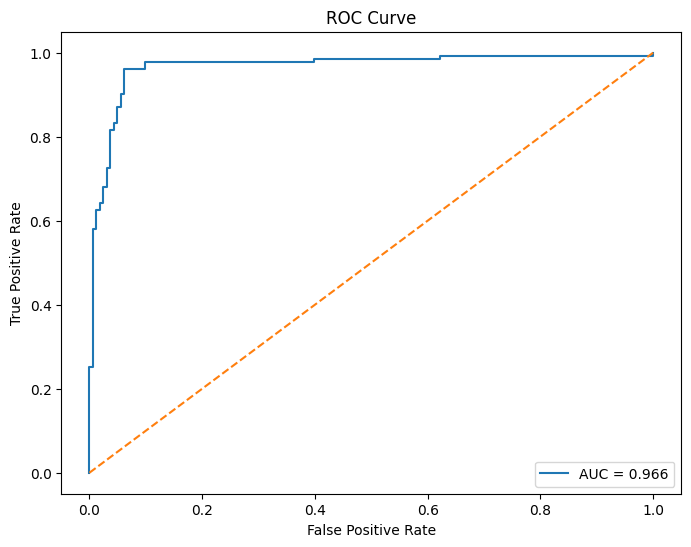

AUC: 0.9663363519984827


In [31]:
fpr, tpr, thresholds = roc_curve(
    y_clf_test,
    y_proba
)

auc = roc_auc_score(
    y_clf_test,
    y_proba
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

print("AUC:", auc)

## 9. Decision Threshold Sensitivity

The default decision threshold of Logistic Regression is 0.50. This experiment evaluates how changing the classification threshold affects Precision, Recall, and F1-score.

In [32]:
thresholds = np.arange(0.30, 0.71, 0.10)

results = []

for threshold in thresholds:

    predictions = (y_proba >= threshold).astype(int)

    precision = precision_score(y_clf_test, predictions)

    recall = recall_score(y_clf_test, predictions)

    f1 = f1_score(y_clf_test, predictions)

    results.append([threshold, precision, recall, f1])

threshold_results = pd.DataFrame(
    results,
    columns=["Threshold", "Precision", "Recall", "F1 Score"]
)

threshold_results

,Threshold,Precision,Recall,F1 Score
0,0.3,0.870748,0.977099,0.920863
1,0.4,0.887324,0.961832,0.923077
2,0.5,0.906475,0.961832,0.933333
3,0.6,0.906475,0.961832,0.933333
4,0.7,0.919708,0.961832,0.940299


## 10. Logistic Regression with Strong Regularization

A second Logistic Regression model is trained with a stronger L2 regularization penalty (`C = 0.01`) to study the effect of regularization on classification performance.

In [33]:
log_model_reg = LogisticRegression(
    C=0.01,
    max_iter=1000
)

log_model_reg.fit(
    X_train_clf_scaled,
    y_clf_train
)

LogisticRegression(C=0.01, max_iter=1000)

In [34]:
y_pred_reglog = log_model_reg.predict(X_test_clf_scaled)

y_proba_reglog = log_model_reg.predict_proba(
    X_test_clf_scaled
)[:,1]

In [35]:
precision_reg = precision_score(
    y_clf_test,
    y_pred_reglog
)

recall_reg = recall_score(
    y_clf_test,
    y_pred_reglog
)

auc_reg = roc_auc_score(
    y_clf_test,
    y_proba_reglog
)

comparison_logistic = pd.DataFrame({
    "Model":[
        "C = 1.0",
        "C = 0.01"
    ],
    "Precision":[
        precision,
        precision_reg
    ],
    "Recall":[
        recall,
        recall_reg
    ],
    "AUC":[
        auc,
        auc_reg
    ]
})

comparison_logistic

,Model,Precision,Recall,AUC
0,C = 1.0,0.919708,0.961832,0.966336
1,C = 0.01,0.940741,0.969466,0.980466


## 11. Bootstrap Confidence Interval for AUC Difference

Bootstrapping is used to estimate the confidence interval for the difference in AUC between the baseline Logistic Regression model (`C=1.0`) and the strongly regularized model (`C=0.01`).

In [36]:
np.random.seed(42)

auc_differences = []

n_bootstrap = 500

for _ in range(n_bootstrap):

    indices = np.random.choice(
        len(y_clf_test),
        size=len(y_clf_test),
        replace=True
    )

    y_true = y_clf_test.iloc[indices]

    proba1 = y_proba[indices]

    proba2 = y_proba_reglog[indices]

    auc1 = roc_auc_score(
        y_true,
        proba1
    )

    auc2 = roc_auc_score(
        y_true,
        proba2
    )

    auc_differences.append(
        auc1 - auc2
    )

mean_difference = np.mean(auc_differences)

lower = np.percentile(
    auc_differences,
    2.5
)

upper = np.percentile(
    auc_differences,
    97.5
)

print("Mean Difference :", mean_difference)
print("Lower 95% CI    :", lower)
print("Upper 95% CI    :", upper)

Mean Difference : -0.014823781355875948
Lower 95% CI    : -0.03009047807587633
Upper 95% CI    : -0.0023875105891979385
